In [18]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import os
from pyshockflow.thesis_plots import *
import pandas as pd
os.makedirs('pics', exist_ok=True)

In [19]:
# INPUT 

pickleFiles = [
    'Results/tank_1e-1_NX_507/Results.pik',
    'Results/tank_1e-2_NX_507/Results.pik',
    'Results/tank_1e-3_NX_507/Results.pik',
    'Results/tank_1e-4_NX_507/Results.pik',
    ]

labels = [
    r'$V_{\rm pl} = 10^{-1}~\rm{m^3}$',
    r'$V_{\rm pl} = 10^{-2}~\rm{m^3}$',
    r'$V_{\rm pl} = 10^{-3}~\rm{m^3}$',
    r'$V_{\rm pl} = 10^{-4}~\rm{m^3}$',
]

totalLength = 3.0284 
time_instant = 0.02 

In [20]:
# SIMULATION DATA TUBE
tubes = []
for pickleFile in pickleFiles:
    with open(pickleFile, 'rb') as file:
        tubes.append(pickle.load(file))
timeshift = 10.3075

# SIMULATION DATA TANK
tankFiles = [
    'Results/tank_1e-1_NX_507/TankHistory_Right.csv',
    'Results/tank_1e-2_NX_507/TankHistory_Right.csv',
    'Results/tank_1e-3_NX_507/TankHistory_Right.csv',
    'Results/tank_1e-4_NX_507/TankHistory_Right.csv',
    ]

tankSols = []
for tankFile in tankFiles:
    tankSols.append(pd.read_csv(tankFile))

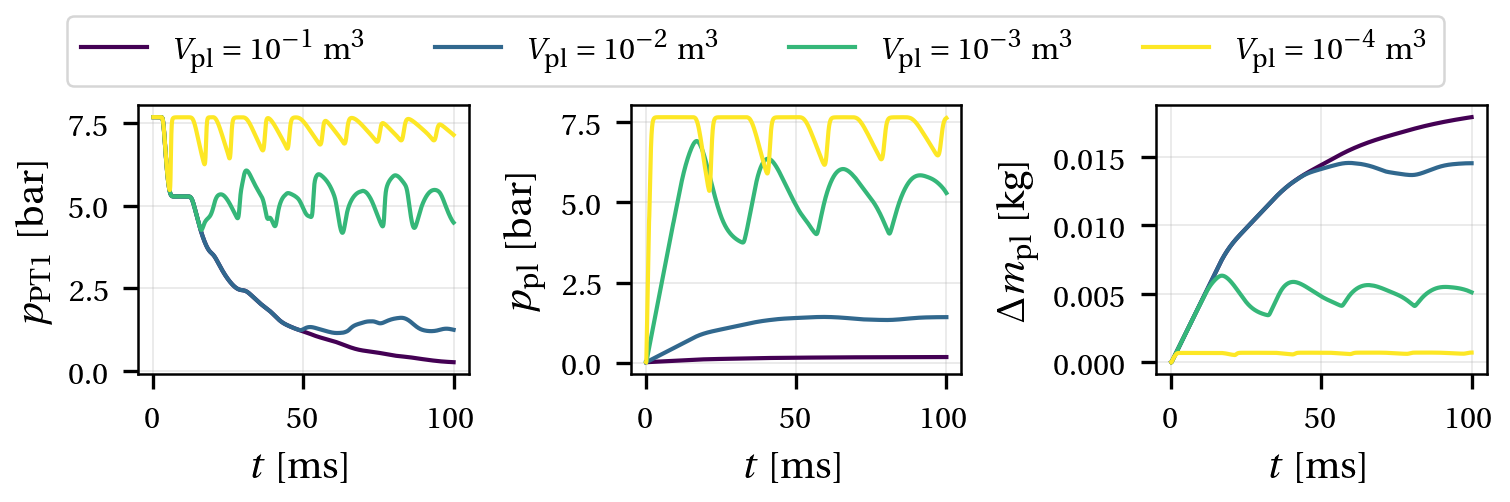

In [28]:
set_thesis_style()
fig, ax = create_figure(fraction=1.00, aspect_ratio=1.0, subplots=(1, 3), is_print=False)
colors = plt.cm.viridis(np.linspace(0,1,len(pickleFiles)))

for ii,tube in enumerate(tubes):
    xCoords = tube['X Coords']               
    pressure = tube['Primitive']['Pressure']  
    time = tube['Time']
    ni,nt = tube['Primitive']['Pressure'].shape

    # find the spatial index associated to every kulite (NOT regular mesh now)
    id1 = np.argmin(np.abs(1.8-xCoords))   
    pressure_PT1 = pressure[id1, :]

    ax[0].plot(time*1e3, pressure_PT1/1e5, '-', color=colors[ii], label=labels[ii])
    
    tankSol = tankSols[ii]
    ax[1].plot(tankSol['Time_s']*1e3, tankSol['Pressure_Pa']/1e5, color=colors[ii])
    ax[2].plot(tankSol['Time_s']*1e3, tankSol['Mass_kg']-tankSol['Mass_kg'][0], color=colors[ii])

for axx in ax:
    axx.set_xlabel(r'$t \ \rm{[ms]}$')
    axx.grid(alpha=.3)
ax[0].set_ylabel(r'$p_{\rm PT1} \ \rm{[bar]}$')
ax[1].set_ylabel(r'$p_{\rm pl} \ \rm{[bar]}$')
ax[2].set_ylabel(r'$\Delta m_{\rm pl} \ \rm{[kg]}$')
fig.legend(loc='outside upper center', ncol=4)



plt.savefig('pics/kulite_pressure_PT1_same_area_different_frictions.pdf')